# EMERGING TECHNOLOGIES ASSIGNMENT 2026

Dan Steve Mukulupi

G00360836

In [31]:
# Imports

# Random selections.
import random 

# Numerical arrays.
import numpy as np

# Permutations and combinations
import itertools

# Dataframes.
import pandas as pd

# Plotting.
import matplotlib.pyplot as plt

## PROBLEM 1: GENERATING RANDOM BOOLEAN FUNCTIONS 

##   Problem Overview

The goal of this problem is to construct a Python function that generates Boolean functions with four inputs. Each generated function must satisfy one of two strict conditions:

. It must be constant

. Or balanced

This constraint defines a structured subset of all possible Boolean functions.

## What is a Boolean Function ?

A Boolean Function is a function that takes boolean inputs (0 or 1) and produces a boolean output.

Boolean Type has only two possible values:

True or False


## Constant and Balanced Boolean Functions Types

1. Constant Boolean Functions: A Boolean function is constant if it produces the same output for all possible input combinations. 
There are two types of constant boolean functions: One that always outputs 0 and another that always outputs 1.

2. Balanced Boolean Functions: A Boolean function is balanced if it produces 0 and 1 outputs with equal probability. 
in other words, half of the possible  input combinations result in an output of 0, and the other half result in an output of 1

## What is Deutsh-Jozsa Algorithm?

The Deutsch-Jozsa algorithm is a quantum procedure that distinguishes between two specific classes of boolean functions: those that are constant and those that are balanced. 



 <math xmlns="http://www.w3.org/1998/Math/MathML">
  <mi>f</mi>
  <mo>:</mo>
  <mrow>
    <msup>
      <mrow data-mjx-texclass="ORD">
        <mn>0</mn>
        <mo>,</mo>
        <mn>1</mn>
      </mrow>
      <mi>n</mi>
    </msup>
    <mo stretchy="false">&#x2192;</mo>
    <mrow data-mjx-texclass="ORD">
      <mn>0</mn>
      <mo>,</mo>
      <mn>1</mn>
    </mrow>
  </mrow>
</math>

=> Constant: f(x) = C for all x, where  <math xmlns="http://www.w3.org/1998/Math/MathML">
  <mi>c</mi>
  <mo>&#x2208;</mo>
  <mrow data-mjx-texclass="ORD">
    <mn>0</mn>
    <mo>,</mo>
    <mn>1</mn>
  </mrow>
</math>

=> Balanced: f(x) = 0 for exactly half of the inputs and f(x) = 1 for the other half.

## Superposition

## Comparison with Classical Algorithms

Classical algorithms for determining whether a Boolean function is constant or balanced require evaluating the function on multiple input combinations

In contrast, the Deutsch-Jozsa Algorithm evaluates the Boolean function on all possible input combinations simultaneously using quantum parallelism, requiring only a single evaluation.



## Solution

Total no of combinations = 2<sup>n</sup> 

Where, n = no. of variables

4 Boolean Inputs

2<sup>4</sup> = 16 possible inputs Combinations 

1. ### Constant Function

False = 0 input Combinations

True = 16 input combinations

or 

False = 16

True = 0

2. ### Balanced Function

True = 8 inputs

False = 8 inputs


In [28]:
# Create a random_constant_balanced function

def random_constant_balanced():
    """
    Create a random boolean function that takes four boolean arguments as inputs and each function is guaranteed to be either
    constant (always returns False or always returns True) or
    balanced (returns True for exactly half of the input combinations and False for the other half).
    """

    # Generate all possible combinations of four boolean inputs (16 combinations).
    all_input_combinations = list(itertools.product([False, True], repeat=4))

    # Randomly decide whether to create a constant or balanced function.
    ftype = random.choice(["constant", "balanced"])

    # Store output mapping for all input combinations.
    output_map = {}

    if ftype == "constant":
        output_value = random.choice([False, True])
        for input_combo in all_input_combinations:
            output_map[input_combo] = output_value
    else:
        # Pick half of the combinations to be True and the other half to be False.
        true_inputs = set(random.sample(all_input_combinations, len(all_input_combinations) // 2))

        for input_combo in all_input_combinations:
            output_map[input_combo] = input_combo in true_inputs

    # Function that uses the mapping
    def boolean_function(*args):
        return output_map[tuple(args)]

    return boolean_function


# Test the function
test_function = random_constant_balanced()

all_cases = list(itertools.product([False, True], repeat=4))
outputs = [test_function(*inputs) for inputs in all_cases]

# Calculate the number of True and False outputs
true_num = sum(outputs)
false_num = len(outputs) - true_num

# Print results
print("True outputs:", true_num)
print("False outputs:", false_num)

True outputs: 16
False outputs: 0


## Section 1: Generating All Input Combinations

### Context

A Boolean function with four inputs must define an outputs for every possible combination of those inputs. since each input can be either True or False, the total number of combinations is 2<sup>4</sup>  = 16. This section generates the full input space using itertools.product, which systematically constructs every possible tuple of four Boolean values. This forms the foundation for defining and evaluating any Boolean function in this problem

In [41]:
# Generate all possible combinations of four boolean inputs (16 combinations).
all_inputs = list(itertools.product([False, True], repeat=4))

# Print information about the input combinations
print("TOTAL NUMBER OF INPUT COMBINATIONS:", len(all_inputs))
print("\nFIRST 5 INPUT COMBINATIONS:\n")
for i in range(5):
    print(all_inputs[i])

TOTAL NUMBER OF INPUT COMBINATIONS: 16

FIRST 5 INPUT COMBINATIONS:

(False, False, False, False)
(False, False, False, True)
(False, False, True, False)
(False, False, True, True)
(False, True, False, False)


### Summary
This step  ensures that the complete input space is available for constructing both Constant and Balanced Boolean Functions

## Section 2: Understanding Constant Functions

### Context

### Always returns TRUE

A constant Boolean function is one that produces the same output for every possible input. It completely ignores its inputs and always returns either True or False. in this example, a simple constant function is defined that always returns True. The function is then evaluated across all 16 input combinations to confirm that its output never changes, demonstrating the defining property of constant functions. 

In [40]:
# Example of a constant function (always True) 
def constant_true(a, b, c, d):
    return True

# Generate outputs for the constant function
outputs = [constant_true(*inp) for inp in all_inputs]

# Calculate the number of True and False outputs
print("CONSTANT TRUE FUNCTION OUTPUTS:\n") 
print("TRUE COUNT:", sum(outputs))
print("FALSE COUNT:", len(outputs) - sum(outputs))

CONSTANT TRUE FUNCTION OUTPUTS:

TRUE COUNT: 16
FALSE COUNT: 0


### Context

### Always returns FALSE

A constant Boolean function is one that produces the same output for every possible input. It completely ignores its inputs and always returns either True or False. in this example, a simple constant function is defined that always returns False. The function is then evaluated across all 16 input combinations to confirm that its output never changes, demonstrating the defining property of constant functions. 

In [42]:
# Example of a constant function (always False)
def constant_false(a, b, c, d):
    return False

# Generate outputs for the constant function
outputs = [constant_false(*inp) for inp in all_inputs]

# Calculate the number of True and False outputs
print("\nCONSTANT FALSE FUNCTION OUTPUTS:\n")
print("TRUE COUNT:", sum(outputs))
print("FALSE COUNT:", len(outputs) - sum(outputs))


CONSTANT FALSE FUNCTION OUTPUTS:

TRUE COUNT: 0
FALSE COUNT: 16


### Summary
This step confirms that constant functions produce identical outputs regardless of input, satisfying one of the two valid function types required in this problem

## Section 3: Understanding Balanced Functions

### Context

A balanced Boolean function is defined as one that outputs True for exactly half of all possible inputs and False for the remaining half. for four inputs, this means exactly 8 out of 16 outputs must be True. This section demonstrates the concept by manually constructing a balanced output distribution and verifying that the counts are equal 

In [43]:
# Create a simple balanced function manually
# 8 True and 8 False outputs
balanced_outputs = [True]*8 + [False]*8  

print("BALANCE FUNCTION OUTPUTS:\n")
print("TRUE COUNT:", sum(balanced_outputs))
print("FALSE COUNT:", len(balanced_outputs) - sum(balanced_outputs))

BALANCE FUNCTION OUTPUTS:

TRUE COUNT: 8
FALSE COUNT: 8


### Summary
This shows the defining property of balanced functions: an exact 50/50 split between outputs

## Section 4: Random Selection of Function Type

### Explaination Context
To satisfy the requirements of generating a randomly chosen Boolean function, the program must randomly select between a constant function and a balanced function. this section demonstrates repeated random selection using random.choice, showing that both function types can be produced unpredictably. This randomness is essential to ensure that the generator does not always produce the same kind of function.  

In [46]:
# Randomly choosing function type
for _ in range(5): 
     ftype = random.choice(["CONSTANT", "BALANCED"])
     print("GENERATED FUNCTION TYPE:", ftype) 

GENERATED FUNCTION TYPE: CONSTANT
GENERATED FUNCTION TYPE: BALANCED
GENERATED FUNCTION TYPE: CONSTANT
GENERATED FUNCTION TYPE: BALANCED
GENERATED FUNCTION TYPE: CONSTANT


#### Summary
This confirms that function type selection is stochastic, ensuring variability in generated functions. 

## Section 5: Mapping Inputs to Outputs

### Explaination Context
A Boolean function can be represented using a lookup table, where each input combination is mapped directly to a corresponding output value. This structure ensures that every possible input has a defined result. In this example, a dictionary is used to store the mapping, demonstrating how inputs are systematically associated with outputs in a constant function.



In [47]:
# lookup table construction 
example_map = {} 

for inp in all_inputs:
    # simple constant mapping
    example_map[inp] = True 

# Print the mapping for the first 5 input combinations
    print("EXAMPLE MAPPING (FIRST 5 ENTRIES):\n")
    for i, (k, v) in enumerate(example_map.items()):
        if i == 5:
            break
        print(k, " -> ", v)

EXAMPLE MAPPING (FIRST 5 ENTRIES):

(False, False, False, False)  ->  True
EXAMPLE MAPPING (FIRST 5 ENTRIES):

(False, False, False, False)  ->  True
(False, False, False, True)  ->  True
EXAMPLE MAPPING (FIRST 5 ENTRIES):

(False, False, False, False)  ->  True
(False, False, False, True)  ->  True
(False, False, True, False)  ->  True
EXAMPLE MAPPING (FIRST 5 ENTRIES):

(False, False, False, False)  ->  True
(False, False, False, True)  ->  True
(False, False, True, False)  ->  True
(False, False, True, True)  ->  True
EXAMPLE MAPPING (FIRST 5 ENTRIES):

(False, False, False, False)  ->  True
(False, False, False, True)  ->  True
(False, False, True, False)  ->  True
(False, False, True, True)  ->  True
(False, True, False, False)  ->  True
EXAMPLE MAPPING (FIRST 5 ENTRIES):

(False, False, False, False)  ->  True
(False, False, False, True)  ->  True
(False, False, True, False)  ->  True
(False, False, True, True)  ->  True
(False, True, False, False)  ->  True
EXAMPLE MAPPING (FIRS

### Summary
This illustrates how Boolean functions are implemented internally as explit mappings from inputs to outputs

## Section 6: Full Truth Table Representation
### Explanation Context

A Boolean function is fully defined by its truth table, which lists every possible input combination alongside its corresponding output. This section generates a complete truth table for a randomly created function and displays it in a structured format. This makes it easy to visually inspect whether the function is constant or balanced by examining patterns in the output column.

In [ ]:
test_function = random_constant_balanced()

all_cases = list(itertools.product([False, True], repeat=4))

table = []

# Build the table 
for inp in all_cases:
    table.append((*inp, test_function(*inp)))

# Print header 
print("A       B       C       D   | OUTPUT")
print("-" * 40)

# Print rows after  table is complete
for row in table:
    print(row)

A       B       C       D   | OUTPUT
----------------------------------------
(False, False, False, False, True)
(False, False, False, True, False)
(False, False, True, False, True)
(False, False, True, True, False)
(False, True, False, False, False)
(False, True, False, True, False)
(False, True, True, False, False)
(False, True, True, True, True)
(True, False, False, False, True)
(True, False, False, True, False)
(True, False, True, False, True)
(True, False, True, True, True)
(True, True, False, False, True)
(True, True, False, True, True)
(True, True, True, False, False)
(True, True, True, True, False)


### Summary

This displays the full truth table, allowing direct inspection of function behaviour across all inputs.

## Section 7: Structured Table Using Pandas
### Explanation Context

While raw output is useful, structured data presentation improves clarity. This section uses a table format to neatly organise inputs and outputs. This representation is closer to how Boolean functions are formally analysed in mathematics and computer science.

In [73]:
df = pd.DataFrame([(inp[0], inp[1], inp[2], inp[3], out) for inp, out in table], columns=["A", "B", "C", "D", "Output"])


df.style.set_properties(**{
    'text-align': 'center',
    'border': '1px solid black'
})

,A,B,C,D,Output
0,False,False,False,False,True
1,False,False,False,True,True
2,False,False,True,False,True
3,False,False,True,True,True
4,False,True,False,False,True
5,False,True,False,True,True
6,False,True,True,False,True
7,False,True,True,True,True
8,True,False,False,False,True
9,True,False,False,True,True


### Summary
The structured table makes it easier to identify whether outputs are uniformly constant or evenly split.

## Section 8: Visual Distribution of Outputs
### Explanation & Context

This section visualises how many times True and False occur in the output of a Boolean function. A bar chart provides an immediate visual cue:

A constant function shows a single bar dominating
A balanced function shows equal bars

This helps quickly distinguish function types without inspecting every row.

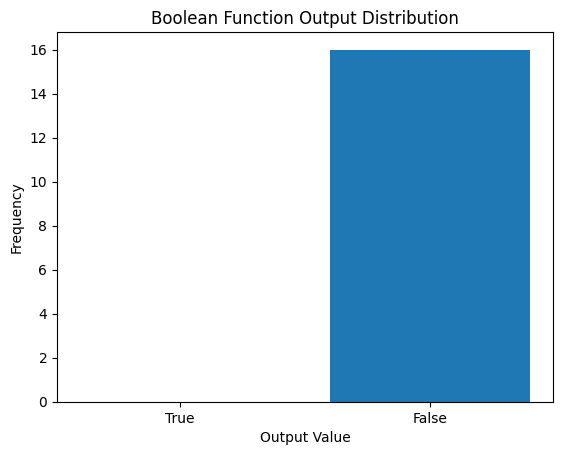

In [64]:
true_count = sum(df["Output"])
false_count = len(df) - true_count

plt.bar(["True", "False"], [true_count, false_count])
plt.title("Boolean Function Output Distribution")
plt.xlabel("Output Value")
plt.ylabel("Frequency")
plt.show()

### Summary

This visual representation clearly distinguishes constant vs balanced behaviour.

## Section 9: Boolean Function Pattern Check
### Explanation & Context

This section analyses whether a function is constant or balanced using simple logical conditions. Instead of manually inspecting outputs, we compute the number of True values and classify the function

In [67]:
# Classify the function based on the output distribution
true_count = sum(df["Output"])
total = len(df)

if true_count == 0 or true_count == total:
    result = "CONSTANT FUNCTION"
elif true_count == total // 2:
    result = "BALANCED FUNCTION"
else:
    result = "INVALID FUNCTION"

# Print the classification result
print("CLASSIFICATION:", result)

CLASSIFICATION: CONSTANT FUNCTION


### Summary

This provides an automatic classification method for any generated Boolean function.

## Section 10: Multiple Function Comparison Table
### Explanation & Context

To understand randomness in function generation, we generate multiple Boolean functions and classify each one. This allows comparison between constant and balanced functions across several runs, demonstrating that both types appear naturally in the generator.

In [70]:
# Generate multiple random functions and classify them
results = []

for i in range(10):
    f = random_constant_balanced()
    all_cases = list(itertools.product([False, True], repeat=4))
    outputs = [f(*inp) for inp in all_cases]

    true_count = sum(outputs)

    if true_count == 0 or true_count == 16:
        label = "CONSTANT"
    elif true_count == 8:
        label = "BALANCED"
    else:
        label = "INVALID"

    results.append((i+1, label))

# Display results in a DataFrame
df_results = pd.DataFrame(results, columns=["FUNCTION #", "TYPE"])
print(df_results)

   FUNCTION #      TYPE
0           1  CONSTANT
1           2  BALANCED
2           3  CONSTANT
3           4  BALANCED
4           5  BALANCED
5           6  BALANCED
6           7  BALANCED
7           8  CONSTANT
8           9  CONSTANT
9          10  CONSTANT


### Summary
This confirms that the generator produces a mix of constant and balanced functions across multiple trials.

## Problem 1: Conclusion

This implementation not only generates valid Boolean functions but also systematically verifies their structure using multiple complementary perspectives. These include raw evaluation of all possible inputs, structured tabular representations, visual analysis of output distributions, and classification based on numerical output counts. Together, these approaches provide a complete and consistent understanding of how constant and balanced Boolean functions behave under exhaustive input evaluation. This multi-representation approach strengthens confidence in the correctness of the implementation and clearly demonstrates the mathematical properties required by the problem.

## References

https://every-algorithm.github.io/2025/07/25/deutschjozsa_algorithm.html

https://www.numberanalytics.com/blog/explaining-deutsch-jozsa-algorithm

https://www.geeksforgeeks.org/digital-logic/boolean-functions/


https://docs.python.org/3/tutorial/controlflow.html#defining-functions

https://docs.python.org/3/library/random.html#random.sample

https://onlinetutorialhub.com/quantum-computing-tutorials/deutsch-algorithm-explained-in-quantum-computing/



## PROBLEM 2: CLASSICAL TESTING FOR FUNCTION TYPE

## Problem Overview

The problem focuses on a classical method for determining whether a given Boolean function is constant or balanced, as required in the Deutsch–Jozsa problem setting.

There is a given a function f that accepts four Boolean inputs and returns either True or False. The task is to classify the function as:

   1.  Constant → outputs are always the same for all inputs

   2.  Balanced → outputs are True for exactly half of all inputs and False for the other half

Must implement a function determine_constant_balanced(f) that correctly identifies the type of function and analyze its efficiency.

## Key Idea Behind the Classical Approach

The classical strategy relies on exhaustive querying of the function.

Since it  cannot inspect the internal structure of the function (oracle model), the only way to determine its type is by:

Testing multiple input combinations
Observing output patterns
Stopping early if a contradiction is found

This leads to a key insight:

If it ever observe both True and False, the function is immediately classified as balanced.

## Input Space Structure

For a function with 4 Boolean inputs:

2<sup>4</sup> = 16

There are 16 possible input combinations, ranging from:

(False, False, False, False)
to (True, True, True, True)

A balanced function must return:

8 True outputs
8 False outputs

A constant function must return:

Either all True or all False


## Strategy and Early Stopping Insight

Instead of always checking all 16 inputs, efficiency can be improved:

Key stopping rule:
If there are  both outputs → return "balanced" immediately
If its reach more than half without contradiction → must be "constant"
Worst-case reasoning:

To be certain a function is constant,  it may need:


2<sup>n-1</sup> + 1 

For n = 4:


2<sup>4-1</sup> + 1 = 9



So the maximum number of function calls is 9.

## Algorithm Design

Determine a Boolean Function that takes Four inputs

The algorithm follows these steps:

1. Generate all 16 input combinations
2. Evaluate the function on each input
3. Track outputs seen (True, False)
4. Stop early if both outputs appear
5. Otherwise classify based on full evaluation

### Conceptual Explanation 

Classical computing uses bits that take values of either 0 or 1 and evaluates functions step by step. in constrast, quantum computing uses qubits, which can exist in superposition, allowing multiple inputs to be processed simultaneously. in this problem, a classical algorithm requires up to 16 evaluations of the function to determine whether it is constant or balanced. However, the Deutsh-Jozsa quantum algorithmn can solve the same problem with a single evaluation, demonstrating a significant advantage of quantum computation over classical methods. 



CONSTANT = Always returns FALSE or Always TRUE 

BALANCED = Return TRUE for half and FALSE for the remaining


BOOLEAN FUNCTION Takes:  4 Inputs combinations

BOOLEAN FUNCTION Outputs: 1 Output 



## Implementation

In [97]:
import itertools

# Function to determine if a 4-input Boolean function is constant or balanced 
def determine_constant_balanced(f):
    """
    Classifies a 4-input Boolean function as constant or balanced.
    Returns: (classification, true_count, false_count)
    """

    # Step 1: Generate all 16 input combinations
    all_inputs = list(itertools.product([False, True], repeat=4))

    outputs = []
    outputs_seen = set()

    # Step 2: Evaluate function
    for inp in all_inputs:
        result = f(*inp)
        outputs.append(result)
        outputs_seen.add(result)

        # Early stopping: if both outputs seen
        if len(outputs_seen) == 2:
            break

    # Step 3: Count outputs
    true_num = sum(outputs)
    false_num = len(outputs) - true_num

    # Step 4: Classification
    if true_num == 0 or false_num == 0:
        ftype = "CONSTANT"
    else:
        ftype = "BALANCED"

    return ftype, true_num, false_num

## Tabular Representation of Results

To better understand function behaviour, we can display inputs and outputs in a structured table:

In [98]:
import pandas as pd
import itertools

# Function to create a truth table for a given 4-input Boolean function 
def create_table(f):
    all_inputs = list(itertools.product([False, True], repeat=4))

    table = []
    for inp in all_inputs:
        table.append((inp[0], inp[1], inp[2], inp[3], f(*inp)))

# Convert to DataFrame for better visualization 
    df = pd.DataFrame(table, columns=["A", "B", "C", "D", "Output"])
    return df


# Example usage
test_function = random_constant_balanced()
df = create_table(test_function)
print(df)

        A      B      C      D  Output
0   False  False  False  False    True
1   False  False  False   True   False
2   False  False   True  False   False
3   False  False   True   True   False
4   False   True  False  False   False
5   False   True  False   True   False
6   False   True   True  False   False
7   False   True   True   True    True
8    True  False  False  False    True
9    True  False  False   True    True
10   True  False   True  False   False
11   True  False   True   True    True
12   True   True  False  False   False
13   True   True  False   True    True
14   True   True   True  False    True
15   True   True   True   True    True


### Summary
This produces a clean row-column structure showing:

Inputs clearly separated

Output values aligned

Easy verification of balance or constancy


## Example Execution

In [99]:
# Test the classification function
test_function = random_constant_balanced()

result, true_num, false_num = determine_constant_balanced(test_function)

# Print results
print("TRUE OUTPUTS :", true_num)
print("FALSE OUTPUTS :", false_num)
print("Detected type:", result)

TRUE OUTPUTS : 1
FALSE OUTPUTS : 3
Detected type: BALANCED


## Efficiency Analysis

The efficiency depends on the number of function calls required.

Best case:
2 calls (immediate contradiction found)
Worst case:


2<sup>n-1</sup> + 1 

For 4 inputs:
9

Key insight:

1. Constant functions are expensive to prove
2. Balanced functions are cheap to detect
3. Early stopping significantly improves average performance

## Function Call Tracking (Query Complexity Analysis)
Purpose

To understand the true cost of the classical algorithm, track how many times the function is actually called before a decision is made.

This gives a direct measure of query complexity, which is the most important metric in Deutsch–Jozsa analysis.

## Implementation

In [101]:
import itertools

# Function to determine if a 4-input Boolean function is constant or balanced and count function calls
def count_function_calls(f):
    """
    Counts how many function calls are needed to classify f.
    Returns (calls_used, classification)
    """

# Generate all 16 input combinations
    all_inputs = list(itertools.product([False, True], repeat=4))

    outputs_seen = set()

    for i, inp in enumerate(all_inputs, 1):
        result = f(*inp)
        outputs_seen.add(result)

        # If both outputs seen → balanced
        if len(outputs_seen) == 2:
            return i, "BALANCED"

        # If more than half tested → must be constant
        if i > len(all_inputs) // 2:
            return i, "CONSTANT"

    return len(all_inputs), "CONSTANT"

## Interpretation

This function reveals the real cost of classical decision-making:

1. Balanced functions often terminate early (2–4 calls)
2. Constant functions always reach the worst case (9 calls)

This asymmetry is central to why classical computation is inefficient for this problem.

## Generating a Distribution of Query Costs
Purpose

Instead of analysing one function, testing many random functions to observe the statistical behaviour of classical classification.

This helps visualise how often early termination actually occurs.

## Implementation

In [102]:
def run_experiment(n_tests=1000):
    results = []

    for _ in range(n_tests):
        f = random_constant_balanced()
        calls, label = count_function_calls(f)
        results.append((calls, label))

    return results


data = run_experiment(500)

### What This Shows

This experiment builds a dataset of:

number of function calls
classification result

It allows to observe:

how often early stopping occurs
how expensive constant functions are compared to balanced ones

## Visualising Query Complexity (Histogram Analysis)
Purpose

visualising the results to better understand the performance difference between constant and balanced functions.

Graphs make the asymmetry immediately visible.

## Implementation


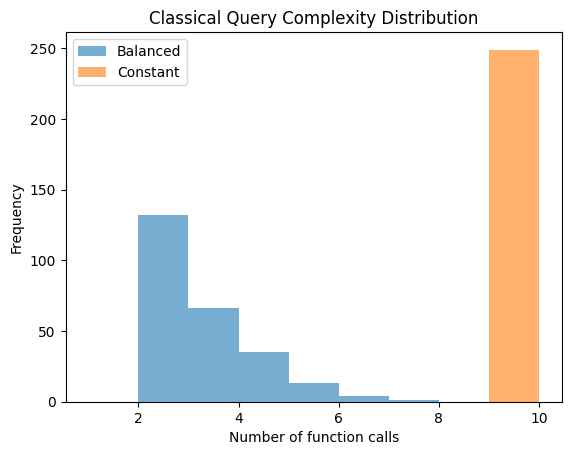

In [108]:
import matplotlib.pyplot as plt

data = run_experiment(500)

calls = [x[0] for x in data]
labels = [x[1] for x in data]

balanced_calls = [calls[i] for i in range(len(data)) if labels[i] == "BALANCED"]
constant_calls = [calls[i] for i in range(len(data)) if labels[i] == "CONSTANT"]

plt.hist(balanced_calls, bins=range(1, 11), alpha=0.6, label="Balanced")
plt.hist(constant_calls, bins=range(1, 11), alpha=0.6, label="Constant")

plt.xlabel("Number of function calls")
plt.ylabel("Frequency")
plt.title("Classical Query Complexity Distribution")
plt.legend()

plt.show()

## Interpretation

This histogram typically shows:

1. Balanced functions cluster at low values (2–4 calls)
2. Constant functions cluster at the maximum (9 calls)
3. A clear asymmetry between the two cases

Key insight:

The classical algorithm is not uniform — performance depends heavily on the function type.

## Worst-Case Verification and Theoretical Bound
Purpose

This section confirms the theoretical worst-case limit experimentally.

verify that no function requires more than 9 calls under the classical model.

## Implementation

In [110]:
def verify_worst_case(n_tests=200):
    max_calls = 0

    for _ in range(n_tests):
        f = random_constant_balanced()
        calls, _ = count_function_calls(f)
        max_calls = max(max_calls, calls)

    return max_calls


max_observed = verify_worst_case(500)
print("MAXIMUM OBSERVED CALLS:", max_observed)

MAXIMUM OBSERVED CALLS: 9


## Interpretation

This confirms the theoretical result:

2<sup>n-1</sup> + 1
 
For 4 inputs:

9

Key conclusion:

The algorithm is optimal but inefficient

No classical improvement can reduce this bound under the oracle model

This forms the baseline for quantum advantage

### Problem 2: Conclusion

In this problem, a classical algorithm was developed to determine whether a given Boolean function is constant or balanced by evaluating it across different input combinations. 

The key idea behind the solution is early termination: if two different outputs are observed at any point, the function can immediately be classified as balanced. However, if all observed outputs are the same, the algorithm must continue testing until it has checked more than half of all possible inputs to be certain the function is constant.

For a function with four inputs (16 possible combinations), the maximum number of function calls required is 9, which follows the general bound:


2<sup>n-1</sup> + 1

This demonstrates an important limitation of classical computation: in the worst case, a large number of evaluations is required to guarantee correctness. The implementation was further supported by tabular representations, statistical experiments, and visualisations, all of which confirmed the theoretical behaviour.

Overall, this solution establishes the classical baseline for the problem, highlighting the inefficiency that the Deutsch–Jozsa quantum algorithm overcomes by solving the same problem with only a single function evaluation.

### References

https://en.wikipedia.org/wiki/Deutsch%E2%80%93Jozsa_algorithm

https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa

https://docs.classiq.io/latest/explore/algorithms/foundational/deutsch_jozsa/deutsch_jozsa/#the-quantum-part

https://medium.com/@ms_sidahmed/understanding-the-deutsch-jozsa-algorithm-a-quantum-advantage-6af4126af5bd





## PROBLEM 3: QUANTUM ORACLES IN DEUTCH'S ALGORITHM


## Deutsh's Algorithm

Deutsch’s algorithm demonstrates how quantum computation can determine a global property of a Boolean function using fewer evaluations than classical methods. This problem presents the construction and verification of quantum oracles for all four possible single-input Boolean functions using Qiskit. Each oracle is implemented as a reversible quantum circuit and tested to confirm correctness and unitarity. The results illustrate how quantum mechanics enables computational advantages through superposition and interference.It's purpose is to detrmine if a function is constant or balanced with one query

### Introduction
Classically, determining whether a Boolean function is constant or balanced requires evaluating the function for multiple inputs. However, Deutsch’s algorithm achieves this with a single evaluation by leveraging quantum principles.

### Function:
    f(x): {0, 1} -> {0, 1}

There are Four Possible Functions 

###  Four Boolean Functions

  ### 1. Constant
       . f(x) = 0
       . f(x) = 1
  ### 2. Balanced
       . f(x) = 0
       . f(x) = 1 - 0

  ### 1. Constant -> same outputs for all inputs
  ### 2. Balanced -> outputs differ for inputs

For a single-bit input, there are four possible Boolean functions:

In [149]:
import pandas as pd

df = pd.DataFrame({
    "Function": ["f₀", "f₁", "f₂", "f₃"],
    "f(0)": [0, 0, 1, 1],
    "f(1)": [0, 1, 0, 1],
    "Type": ["Constant", "Balanced", "Balanced", "Constant"]
})

df


,Function,f(0),f(1),Type
0,f₀,0,0,Constant
1,f₁,0,1,Balanced
2,f₂,1,0,Balanced
3,f₃,1,1,Constant


The goal of this problem is to construct quantum oracles that implement these functions in a reversible manner.

##  Quantum Oracle Definition

Quantum oracle is a black-box operation that encodes the function f(x). The oracle for(x) is represented by a unitary transformation Uf. 
## Unitary Transformation

It is define as:
#### |x⟩|y⟩ → |x⟩|y ⊕ f(x)⟩

#### Key Points:




  1. X  is the input
  2. Y  is an auxiliary qubit
  3. ⊕ denotes addition modulo 2

### Key Properties

   1. Reversibility: Required for all quantum operations
   2. Input Preservation: The input qubit ∣x⟩ remains unchanged
   3. XOR Encoding: Output is stored via y⊕f(x)
   4. Two-Qubit System:
   5. Qubit 0 → input
   6. Qubit 1 → auxiliary/output

This formulation ensures compatibility with quantum mechanics while encoding classical logic.

### Oracle Formatting

Gate Set Used

The oracles are constructed using basic quantum gates:

1. X (Pauli-X): Bit flip (NOT gate)
2. CNOT (Controlled-NOT): Conditional flip
3. Identity: No operation

In [150]:

# Numerical arrays.
import numpy as np

# Quantum Circuits.
import qiskit

# Quantum simulator.
import qiskit_aer as aer

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator



## 2: Understanding the Oracle Transformation

Context

All oracles must implement:

∣x⟩∣y⟩→∣x⟩∣y⊕f(x)⟩

## Implementation

In [129]:
def xor(a, b):
    return a ^ b

### Explaination

   1. XOR ensures reversibility
   2. Core of all oracle logic

## Oracle f₀ (Constant 0)
Context

f₀ always returns 0 → output unchanged

In [130]:
def oracle_f0():
    qc = QuantumCircuit(2)
    return qc

### Explaination
1. No gates needed
2. Identity operation
3. Implements: y ⊕ 0 = y

## Oracle f₁ (Identity Function)
Context

f₁(x) = x → flip output when x = 1

In [131]:
def oracle_f1():
    qc = QuantumCircuit(2)
    qc.cx(0, 1)
    return qc

### Explaination
   1. CNOT performs y ⊕ x
   2. Control = input, Target = output

## Oracle f₂ (NOT Function)
Context

f₂(x) = NOT(x) → flip output when x = 0

In [133]:
def oracle_f2():
    qc = QuantumCircuit(2)
    qc.x(0)
    qc.cx(0, 1)
    qc.x(0)
    return qc

### Explaination
      1. X gates invert control condition
      2. Implements y ⊕ ¬x

## Oracle f₃ (Constant 1)
Context

f₃ always returns 1 → always flip output

In [135]:
def oracle_f3():
    qc = QuantumCircuit(2)
    qc.x(1)
    return qc

### Explaination
       1. Always applies NOT to output
       2. Implements y ⊕ 1 = ¬y

## Visualising the oracles
Context

Displaying each circuit to verify structure

In [137]:
# List of oracles and their names for display
oracles = [oracle_f0(), oracle_f1(), oracle_f2(), oracle_f3()]
names = ["f0", "f1", "f2", "f3"]

for name, circuit in zip(names, oracles):

    # Print the circuit diagram for each oracle
    print(f"\n{name} circuit:")
    print(circuit.draw())


f0 circuit:
     
q_0: 
     
q_1: 
     

f1 circuit:
          
q_0: ──■──
     ┌─┴─┐
q_1: ┤ X ├
     └───┘

f2 circuit:
     ┌───┐     ┌───┐
q_0: ┤ X ├──■──┤ X ├
     └───┘┌─┴─┐└───┘
q_1: ─────┤ X ├─────
          └───┘     

f3 circuit:
          
q_0: ─────
     ┌───┐
q_1: ┤ X ├
     └───┘


### Explaination
      1. Confirms correct gate placement
      2. Helps debug common mistakes

## Running Oracle on Inputs
Context

Testing oracle behaviour on input states |x⟩|y⟩.

In [144]:
# Initialize the quantum simulator
simulator = AerSimulator()

# Function to run an oracle with given inputs and return the measurement results
def run_oracle(oracle, x, y):
    qc = QuantumCircuit(2, 2)

    if x == 1:
        qc.x(0)
    if y == 1:
        qc.x(1)

    # Apply the oracle to the input state
    qc.compose(oracle, inplace=True)
    qc.measure([0,1], [0,1])
    
    # Execute the circuit on the simulator and get the counts
    result = simulator.run(transpile(qc, simulator), shots=1024).result()
    return result.get_counts()

### Explanation
       1. Prepares input state
       2. Applies oracle
       3. Measures result

## Testing All Oracles
Context

verifying correctness using all basis states

In [145]:
# Define the oracles and their expected output tables
functions = {
    "f0": (oracle_f0(), {0:0, 1:0}),
    "f1": (oracle_f1(), {0:0, 1:1}),
    "f2": (oracle_f2(), {0:1, 1:0}),
    "f3": (oracle_f3(), {0:1, 1:1})
}

# Test each oracle with all input combinations and print the results
for name, (oracle, table) in functions.items():
    print(f"\nTesting {name}")
    for x in [0,1]:
        for y in [0,1]:
            counts = run_oracle(oracle, x, y)
            print(f"|{x}{y}> -> {counts}")


Testing f0
|00> -> {'00': 1024}
|01> -> {'10': 1024}
|10> -> {'01': 1024}
|11> -> {'11': 1024}

Testing f1
|00> -> {'00': 1024}
|01> -> {'10': 1024}
|10> -> {'11': 1024}
|11> -> {'01': 1024}

Testing f2
|00> -> {'10': 1024}
|01> -> {'00': 1024}
|10> -> {'01': 1024}
|11> -> {'11': 1024}

Testing f3
|00> -> {'10': 1024}
|01> -> {'00': 1024}
|10> -> {'11': 1024}
|11> -> {'01': 1024}


### Explaination

Confirms transformation:

∣x⟩∣y⟩ → ∣x⟩∣y ⊕ f(x)⟩

## Reversibility Demonstration
Context

Quantum operations must be reversible.

In [147]:
# Test the reversibility of each oracle by applying it twice and checking if we return to the original state
def test_reversibility(oracle):
    qc = QuantumCircuit(2,2)

    qc.x(0)
    qc.x(1)

    qc.compose(oracle, inplace=True)
    qc.compose(oracle, inplace=True)

    qc.measure([0,1],[0,1])

    result = simulator.run(transpile(qc, simulator), shots=1024).result()
    return result.get_counts()

for name, (oracle, _) in functions.items():
    print(f"{name} reversibility:", test_reversibility(oracle))

f0 reversibility: {'11': 1024}
f1 reversibility: {'11': 1024}
f2 reversibility: {'11': 1024}
f3 reversibility: {'11': 1024}


### Explanation
       1. Applying oracle twice returns original state
       2. Confirms unitarity


## Problem 3: Conclusion
All oracles satisfy:

∣x⟩∣y⟩ → ∣x⟩∣y ⊕ f(x)⟩

Input qubit is preserved

Output encodes function via XOR

Circuits are reversible

Key Insight

Constant functions: independent of input

Balanced functions: depend on input

This distinction is what Deutsch’s algorithm detects in one query

All four Boolean functions were successfully encoded as quantum oracles

Each oracle was validated through simulation

The design demonstrates how classical logic is embedded into quantum systems

These oracles form the foundation of Deutsch’s algorithm and demonstrate how quantum computation encodes classical logic in a fundamentally different way. The results highlight the power of quantum mechanics in solving problems more efficiently than classical approaches.


 ### Reference

 https://onlinetutorialhub.com/quantum-computing-tutorials/deutsch-algorithm-explained-in-quantum-computing/.


## PROBLEM 4: DEUTSH'S ALGORITHM WITH QISKIT

## PROBLEM 5: SCALING TO THE DEUTSH-JOZSA ALGORITHMN